<div style=" background-color: #940D0D;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Produisez une étude de marché
</h2>
</div>

<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

# Notebook 3 - ACP et Clustering

## Objectif
Ce notebook applique des techniques de réduction de dimensionnalité et de clustering à l'ensemble de données analytique final.

Objectifs principaux :

- Charger l'ensemble de données final nettoyé
- Standardiser les variables
- Effectuer une ACP
- Analyser la variance expliquée
- Interpréter les composantes principales
- Visualiser les pays sur les axes de l'ACP
- Appliquer un clustering hiérarchique
- Appliquer un clustering K-means
- Comparer les résultats du clustering
- Identifier les groupes de pays et les interpréter

</div>

<div style="background-color:#940D0D ;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Étape 1 - Charger tous les jeux de données bruts</h2>
</div>

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">1.1 - Import of bookstores</h3>
</div>

In [47]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


In [48]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [49]:
data_path = "../data_clean/dataset_2017_final_model_for_pca_v3.csv"

df = pd.read_csv(data_path)

print("Shape:", df.shape)
display(df.head().T)
display(df.columns.tolist())

Shape: (309, 9)


,0,1,2,3,4
country,Afghanistan,Albania,Algeria,American Samoa,Andorra
population_2017,"36,296.113","2,884.169","41,389.189","5,447.900",77.001
population_cagr_2000_2017,0.033,-0.005,0.017,0.012,0.010
gdp_per_capita_2017,530.150,"4,521.752","4,134.936","6,450.320","40,632.206"
gdp_pc_growth_2017,1.902,9.831,4.228,6.002,1.825
political_stability_2017,-2.800,0.380,-0.920,1.220,1.420
protein_kcal_ratio,0.027,0.035,0.028,0.028,0.028
poultry_kcal_per_capita_day_2017,5.000,85.000,22.000,64.000,64.000
poultry_import_1000_tonnes_2017,29.000,38.000,2.000,16.000,16.000


['country',
 'population_2017',
 'population_cagr_2000_2017',
 'gdp_per_capita_2017',
 'gdp_pc_growth_2017',
 'political_stability_2017',
 'protein_kcal_ratio',
 'poultry_kcal_per_capita_day_2017',
 'poultry_import_1000_tonnes_2017']

In [50]:
print(df.info())

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicated countries:", df["country"].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country                           309 non-null    object 
 1   population_2017                   309 non-null    float64
 2   population_cagr_2000_2017         309 non-null    float64
 3   gdp_per_capita_2017               309 non-null    float64
 4   gdp_pc_growth_2017                309 non-null    float64
 5   political_stability_2017          309 non-null    float64
 6   protein_kcal_ratio                309 non-null    float64
 7   poultry_kcal_per_capita_day_2017  309 non-null    float64
 8   poultry_import_1000_tonnes_2017   309 non-null    float64
dtypes: float64(8), object(1)
memory usage: 21.9+ KB
None

Missing values:


country                             0
population_2017                     0
population_cagr_2000_2017           0
gdp_per_capita_2017                 0
gdp_pc_growth_2017                  0
political_stability_2017            0
protein_kcal_ratio                  0
poultry_kcal_per_capita_day_2017    0
poultry_import_1000_tonnes_2017     0
dtype: int64


Duplicated countries: 0


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">Définition des variables natives</h3>
</div>

In [51]:
features_original = [
    "population_2017",
    "population_cagr_2000_2017",
    "gdp_per_capita_2017",
    "gdp_pc_growth_2017",
    "political_stability_2017",
    "protein_kcal_ratio",
    "poultry_kcal_per_capita_day_2017",
    "poultry_import_1000_tonnes_2017"
]

print("Number of original features:", len(features_original))
print(features_original)

Number of original features: 8
['population_2017', 'population_cagr_2000_2017', 'gdp_per_capita_2017', 'gdp_pc_growth_2017', 'political_stability_2017', 'protein_kcal_ratio', 'poultry_kcal_per_capita_day_2017', 'poultry_import_1000_tonnes_2017']


In [52]:
display(df[features_original].describe().T)

,count,mean,std,min,25%,50%,75%,max
population_2017,309.000,"25,674.451","115,747.467",0.793,"1,384.059","5,447.900","11,339.254","1,421,021.791"
population_cagr_2000_2017,309.000,0.013,0.012,-0.012,0.006,0.012,0.017,0.094
gdp_per_capita_2017,309.000,"13,576.326","21,651.322",295.621,"4,041.995","6,450.320","11,020.663","173,611.815"
gdp_pc_growth_2017,309.000,5.909,6.170,-29.218,4.514,6.002,7.249,32.525
political_stability_2017,309.000,-0.093,0.766,-2.940,-0.250,-0.045,0.160,1.920
protein_kcal_ratio,309.000,0.028,0.003,0.019,0.028,0.028,0.029,0.041
poultry_kcal_per_capita_day_2017,309.000,69.877,45.437,0.000,56.000,64.000,70.000,243.000
poultry_import_1000_tonnes_2017,309.000,56.453,143.046,0.000,14.000,16.000,21.000,"1,069.000"


<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

## Définissez les variables à analyser.

- Variables économiques

- Variables démographiques

- Variables nutritionnelles

-  Variables directement liées à la volaille

</div>

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">correlation matrix</h3>
</div>


,population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,poultry_import_1000_tonnes_2017
population_2017,1.000,-0.006,-0.032,0.046,-0.106,-0.005,-0.049,0.187
population_cagr_2000_2017,-0.006,1.000,-0.045,-0.188,-0.151,-0.238,-0.201,-0.030
gdp_per_capita_2017,-0.032,-0.045,1.000,-0.072,0.257,0.314,0.249,0.149
gdp_pc_growth_2017,0.046,-0.188,-0.072,1.000,0.041,0.037,0.018,0.014
political_stability_2017,-0.106,-0.151,0.257,0.041,1.000,0.161,0.210,0.015
protein_kcal_ratio,-0.005,-0.238,0.314,0.037,0.161,1.000,0.412,0.176
poultry_kcal_per_capita_day_2017,-0.049,-0.201,0.249,0.018,0.210,0.412,1.000,0.197
poultry_import_1000_tonnes_2017,0.187,-0.030,0.149,0.014,0.015,0.176,0.197,1.000


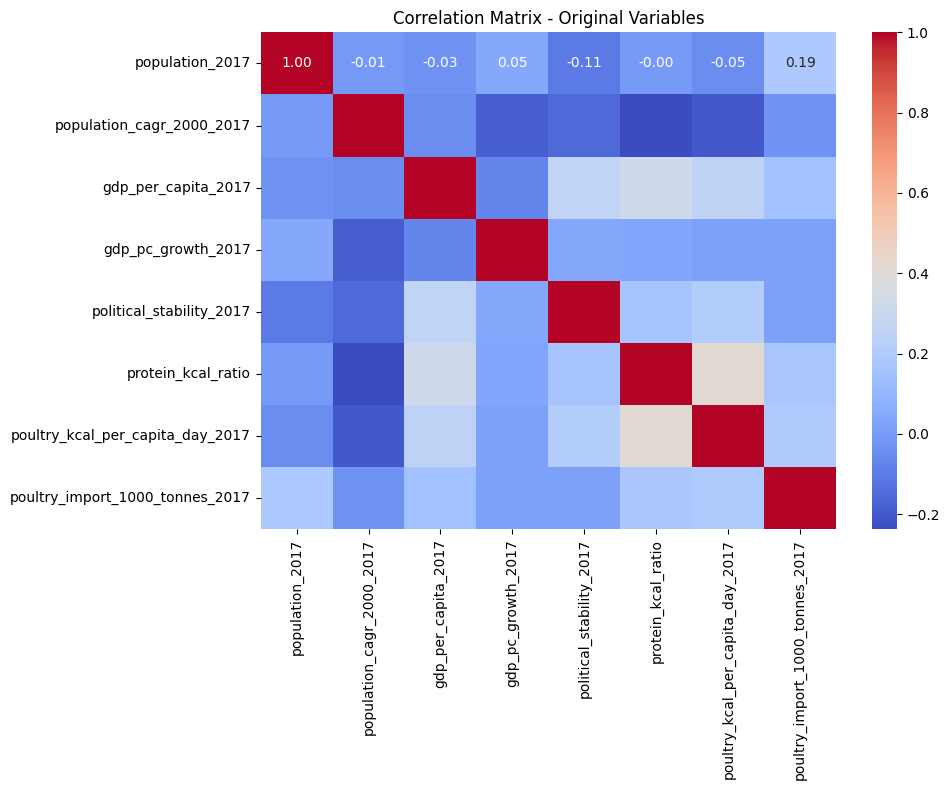

In [53]:
corr_matrix_original = df[features_original].corr()

display(corr_matrix_original)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_original, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix - Original Variables")
plt.tight_layout()
plt.show()

<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

 
## Comprendre les relations entre les variables avant l'optimisation.

Résultat

Observation :

- Relations fortes

- Relations modérées

- Certaines variables présentent-elles des dimensions similaires ?

</div>

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">Création de la version améliorée </h3>
</div>


In [54]:
df_improved = df.copy()

df_improved["log_population_2017"] = np.log1p(df_improved["population_2017"])
df_improved["log_poultry_import_1000_tonnes_2017"] = np.log1p(df_improved["poultry_import_1000_tonnes_2017"])

display(df_improved[[
    "country",
    "population_2017",
    "log_population_2017",
    "poultry_import_1000_tonnes_2017",
    "log_poultry_import_1000_tonnes_2017"
]].head())

,country,population_2017,log_population_2017,poultry_import_1000_tonnes_2017,log_poultry_import_1000_tonnes_2017
0,Afghanistan,"36,296.113",10.499,29.000,3.401
1,Albania,"2,884.169",7.967,38.000,3.664
2,Algeria,"41,389.189",10.631,2.000,1.099
3,American Samoa,"5,447.900",8.603,16.000,2.833
4,Andorra,77.001,4.357,16.000,2.833


In [55]:
#Réduction de l'impact de l'asymétrie extrême des variables volumétriques.
#Résultat :
#Construction d'une version plus équilibrée des données sans suppression des informations originales.

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">Comparaison de la distribution avant et après log </h3>
</div>


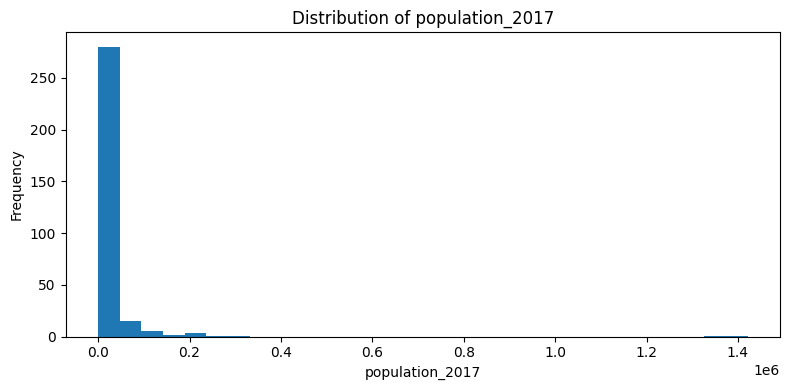

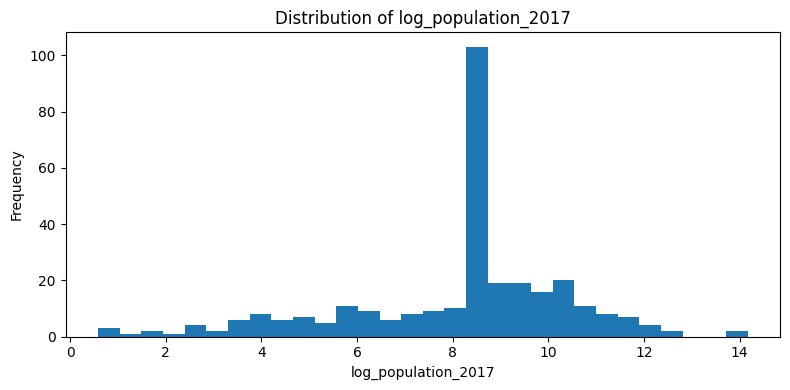

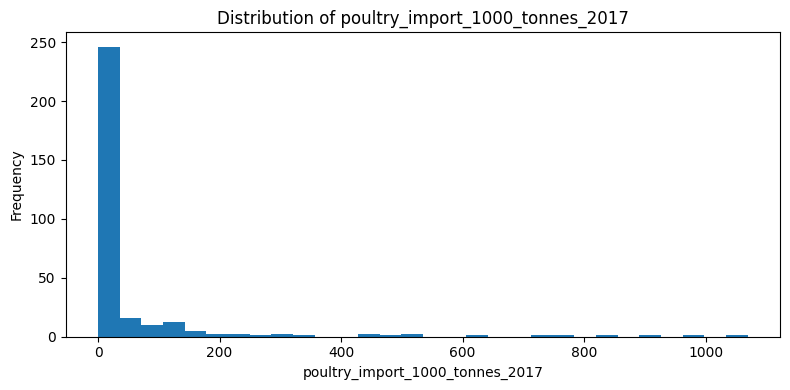

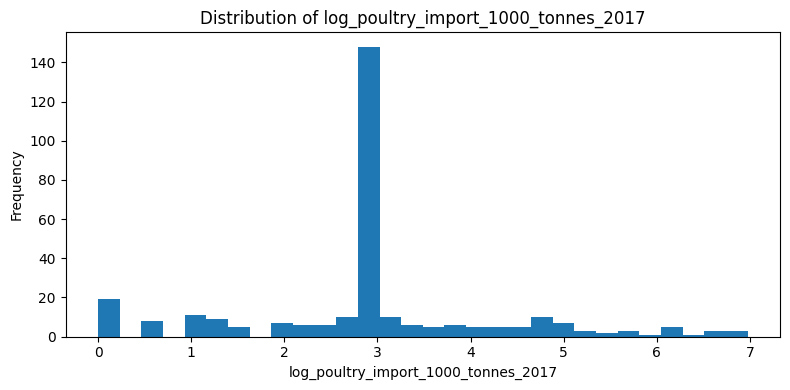

In [56]:
log_compare_cols = [
    ("population_2017", "log_population_2017"),
    ("poultry_import_1000_tonnes_2017", "log_poultry_import_1000_tonnes_2017")
]

for original_col, log_col in log_compare_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df_improved[original_col].dropna(), bins=30)
    plt.title(f"Distribution of {original_col}")
    plt.xlabel(original_col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(df_improved[log_col].dropna(), bins=30)
    plt.title(f"Distribution of {log_col}")
    plt.xlabel(log_col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">


J'ai tracé l'histogramme :

- Pour la variable originale

- Puis pour sa version logarithmique

Résultat :

On observe :

- La distribution originale est fortement asymétrique

- La distribution après transformation logarithmique est plus équilibrée

</div>



In [57]:
#Définir l'ensemble des variables finales optimisées
features = [
    "log_population_2017",
    "population_cagr_2000_2017",
    "gdp_per_capita_2017",
    "gdp_pc_growth_2017",
    "political_stability_2017",
    "protein_kcal_ratio",
    "poultry_kcal_per_capita_day_2017",
    "log_poultry_import_1000_tonnes_2017"
]

print("Number of improved features:", len(features))
print(features)

Number of improved features: 8
['log_population_2017', 'population_cagr_2000_2017', 'gdp_per_capita_2017', 'gdp_pc_growth_2017', 'political_stability_2017', 'protein_kcal_ratio', 'poultry_kcal_per_capita_day_2017', 'log_poultry_import_1000_tonnes_2017']


In [58]:
display(df_improved[features].describe().T)

,count,mean,std,min,25%,50%,75%,max
log_population_2017,309.000,8.153,2.345,0.584,7.233,8.603,9.336,14.167
population_cagr_2000_2017,309.000,0.013,0.012,-0.012,0.006,0.012,0.017,0.094
gdp_per_capita_2017,309.000,"13,576.326","21,651.322",295.621,"4,041.995","6,450.320","11,020.663","173,611.815"
gdp_pc_growth_2017,309.000,5.909,6.170,-29.218,4.514,6.002,7.249,32.525
political_stability_2017,309.000,-0.093,0.766,-2.940,-0.250,-0.045,0.160,1.920
protein_kcal_ratio,309.000,0.028,0.003,0.019,0.028,0.028,0.029,0.041
poultry_kcal_per_capita_day_2017,309.000,69.877,45.437,0.000,56.000,64.000,70.000,243.000
log_poultry_import_1000_tonnes_2017,309.000,2.894,1.393,0.000,2.708,2.833,3.091,6.975


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">Matrice de corrélation améliorée </h3>
</div>



,log_population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,log_poultry_import_1000_tonnes_2017
log_population_2017,1.000,0.227,-0.187,0.080,-0.235,-0.095,-0.142,0.145
population_cagr_2000_2017,0.227,1.000,-0.045,-0.188,-0.151,-0.238,-0.201,-0.119
gdp_per_capita_2017,-0.187,-0.045,1.000,-0.072,0.257,0.314,0.249,0.176
gdp_pc_growth_2017,0.080,-0.188,-0.072,1.000,0.041,0.037,0.018,0.028
political_stability_2017,-0.235,-0.151,0.257,0.041,1.000,0.161,0.210,0.108
protein_kcal_ratio,-0.095,-0.238,0.314,0.037,0.161,1.000,0.412,0.177
poultry_kcal_per_capita_day_2017,-0.142,-0.201,0.249,0.018,0.210,0.412,1.000,0.231
log_poultry_import_1000_tonnes_2017,0.145,-0.119,0.176,0.028,0.108,0.177,0.231,1.000


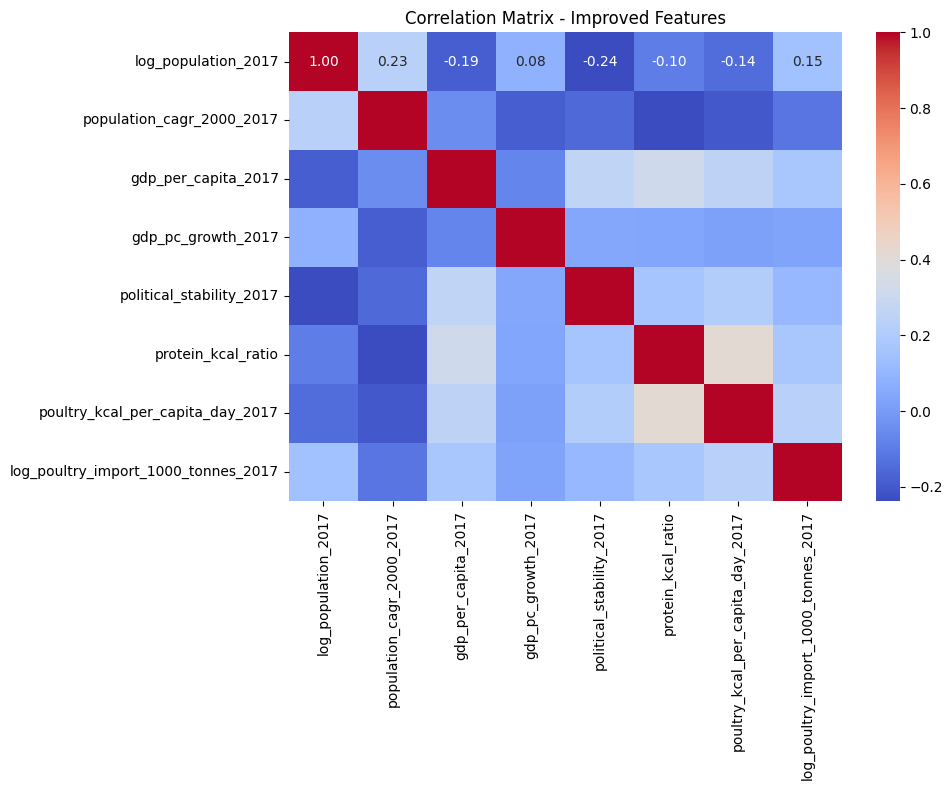

In [59]:
corr_matrix_improved = df_improved[features].corr()

display(corr_matrix_improved)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_improved, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix - Improved Features")
plt.tight_layout()
plt.show()


<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">


Objectif :

- Comprendre les relations entre les variables après transformation.

Résultat :

- Les relations sont plus claires et l’influence de la taille brute est réduite.

</div>



<div style="background-color:#940D0D ;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Standardization</h2>


</div>

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_improved[features])

df_scaled = pd.DataFrame(X_scaled, columns=features, index=df_improved.index)
display(df_scaled.head())

,log_population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,log_poultry_import_1000_tonnes_2017
0,1.002,1.703,-0.604,-0.650,-3.541,-0.409,-1.430,0.365
1,-0.079,-1.497,-0.419,0.637,0.619,2.475,0.333,0.554
2,1.058,0.337,-0.437,-0.273,-1.082,-0.169,-1.055,-1.290
3,0.192,-0.114,-0.330,0.015,1.717,0.041,-0.130,-0.043
4,-1.622,-0.285,1.252,-0.663,1.979,0.041,-0.130,-0.043


In [61]:
print("Means (devrait être proche de 0):")
display(df_scaled.mean().round(4))

print("Std devs (should be close to 1):")
display(df_scaled.std().round(4))

Means (devrait être proche de 0):


log_population_2017                   -0.000
population_cagr_2000_2017             -0.000
gdp_per_capita_2017                    0.000
gdp_pc_growth_2017                    -0.000
political_stability_2017              -0.000
protein_kcal_ratio                    -0.000
poultry_kcal_per_capita_day_2017       0.000
log_poultry_import_1000_tonnes_2017    0.000
dtype: float64

Std devs (should be close to 1):


log_population_2017                   1.002
population_cagr_2000_2017             1.002
gdp_per_capita_2017                   1.002
gdp_pc_growth_2017                    1.002
political_stability_2017              1.002
protein_kcal_ratio                    1.002
poultry_kcal_per_capita_day_2017      1.002
log_poultry_import_1000_tonnes_2017   1.002
dtype: float64


<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">


### Avantage

Mettre toutes les variables sur la même échelle.

#### Pourquoi ?

Parce que :

- Revenu par habitant

- Population

- Stabilité politique

- Taux de protéines

- ne sont pas sur la même échelle.

#### Résultat souhaité

Données :

-  Moyenne ≈ 0

-  Écart type ≈ 1

</div>



<div style="background-color:#940D0D ;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Exécuter l'ACP</h2>
</div>

In [62]:
#L'ACP a été mise en œuvre sur des données standardisées.
#Réduction dimensionnelle et extraction des axes clés expliquant les différences entre pays.

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("X_pca shape:", X_pca.shape)

X_pca shape: (309, 8)


In [63]:
explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(features))],
    "eigenvalue": pca.explained_variance_,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})

display(explained_variance)

,component,eigenvalue,explained_variance_ratio,cumulative_explained_variance
0,PC1,2.153,0.268,0.268
1,PC2,1.227,0.153,0.421
2,PC3,1.168,0.146,0.567
3,PC4,0.878,0.109,0.676
4,PC5,0.794,0.099,0.775
5,PC6,0.692,0.086,0.861
6,PC7,0.610,0.076,0.937
7,PC8,0.504,0.063,1.000


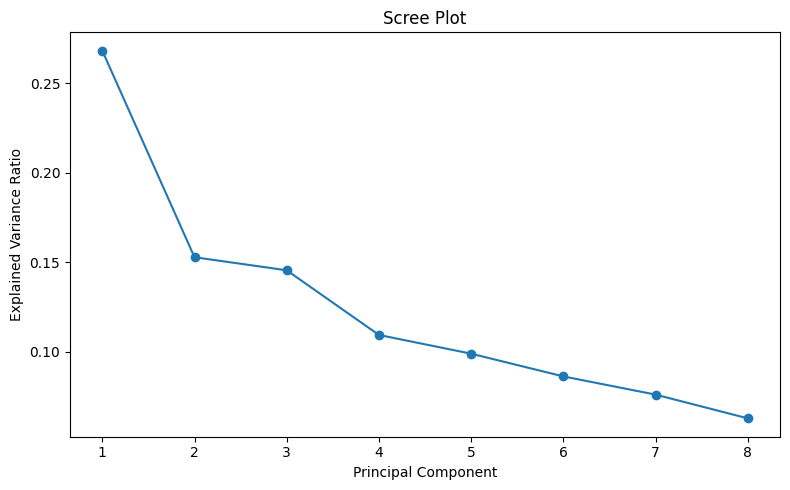

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(features) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, len(features) + 1))
plt.tight_layout()
plt.show()

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">
Variance expliquée cumulée </h3>
</div>



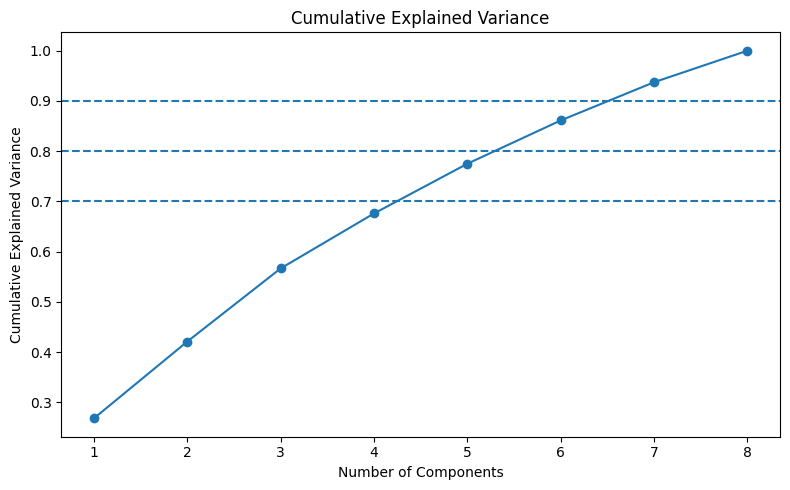

In [65]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(features) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.axhline(y=0.70, linestyle="--")
plt.axhline(y=0.80, linestyle="--")
plt.axhline(y=0.90, linestyle="--")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(range(1, len(features) + 1))
plt.tight_layout()
plt.show()

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">
scores CAP </h3>
</div>




In [66]:
#Voici les coordonnées des pays situés dans le nouvel espace.
pca_cols = [f"PC{i+1}" for i in range(len(features))]

df_pca_scores = pd.DataFrame(X_pca, columns=pca_cols, index=df_improved.index)
df_pca_scores["country"] = df_improved["country"].values

display(df_pca_scores.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,country
0,-3.193,1.198,1.486,1.631,0.219,1.395,-0.712,0.764,Afghanistan
1,2.074,0.909,-1.090,0.780,0.041,-0.176,1.321,1.026,Albania
2,-1.908,0.016,0.049,0.686,0.694,0.290,0.828,-0.334,Algeria
3,0.434,-0.264,-0.262,-1.123,-0.237,-0.881,0.838,0.077,American Samoa
4,1.684,-1.984,0.247,-1.238,-0.406,0.207,0.256,0.127,Andorra


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">
Loadings </h3>
</div>


In [67]:
#Calculez ici les charges des composants.
#Comprenez la signification de chaque composant.
loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=features,
    columns=pca_cols
)

display(loadings)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
log_population_2017,-0.394,0.729,0.237,-0.085,0.137,-0.120,0.356,-0.307
population_cagr_2000_2017,-0.489,-0.052,0.612,-0.231,0.391,-0.213,-0.244,0.274
gdp_per_capita_2017,0.598,-0.150,0.398,-0.212,0.298,0.507,-0.050,-0.267
gdp_pc_growth_2017,0.077,0.424,-0.694,-0.302,0.422,0.082,-0.230,0.082
political_stability_2017,0.542,-0.265,-0.056,-0.650,-0.073,-0.362,0.277,0.010
protein_kcal_ratio,0.686,0.175,0.086,0.369,0.317,-0.008,0.353,0.365
poultry_kcal_per_capita_day_2017,0.690,0.152,0.104,0.272,0.073,-0.462,-0.362,-0.262
log_poultry_import_1000_tonnes_2017,0.391,0.606,0.276,-0.218,-0.494,0.153,-0.190,0.234


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">
Loadings  sur PC1 et PC2 </h3>
</div>



In [68]:
print("Loadings on PC1:")
display(loadings[["PC1"]].sort_values(by="PC1", ascending=False))

print("Loadings on PC2:")
display(loadings[["PC2"]].sort_values(by="PC2", ascending=False))

Loadings on PC1:


,PC1
poultry_kcal_per_capita_day_2017,0.690
protein_kcal_ratio,0.686
gdp_per_capita_2017,0.598
political_stability_2017,0.542
log_poultry_import_1000_tonnes_2017,0.391
gdp_pc_growth_2017,0.077
log_population_2017,-0.394
population_cagr_2000_2017,-0.489


Loadings on PC2:


,PC2
log_population_2017,0.729
log_poultry_import_1000_tonnes_2017,0.606
gdp_pc_growth_2017,0.424
protein_kcal_ratio,0.175
poultry_kcal_per_capita_day_2017,0.152
population_cagr_2000_2017,-0.052
gdp_per_capita_2017,-0.150
political_stability_2017,-0.265


<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

##  Interprétation des Loadings — Signification des Axes

### Axe PC1 — « Niveau de développement & consommation de volaille »

PC1 représente **le niveau de développement économique et nutritionnel d'un pays**.

Les variables qui contribuent le plus positivement à PC1 :
- **poultry_kcal_per_capita_day_2017** (loading = +0.690) : consommation de volaille par habitant
- **protein_kcal_ratio** (loading = +0.686) : part des protéines dans l'alimentation
- **gdp_per_capita_2017** (loading = +0.598) : richesse par habitant
- **political_stability_2017** (loading = +0.542) : stabilité politique

Les variables qui contribuent négativement :
- **population_cagr_2000_2017** (loading = -0.489) : croissance démographique rapide
- **log_population_2017** (loading = -0.394) : grande taille de population

**Un pays avec un PC1 élevé** est riche, stable, consomme beaucoup de volaille et a une population plutôt stable.  
**Un pays avec un PC1 faible** est pauvre, instable, peu consommateur de volaille et à forte croissance démographique.

---

### Axe PC2 — « Taille et poids démographique & commercial »

PC2 représente **la taille absolue du pays (démographique et en termes d'échanges commerciaux)**.

Les variables qui contribuent le plus positivement à PC2 :
- **log_population_2017** (loading = +0.729) : grande population
- **log_poultry_import_1000_tonnes_2017** (loading = +0.606) : volume élevé d'importations de volaille
- **gdp_pc_growth_2017** (loading = +0.424) : croissance économique dynamique

**Un pays avec un PC2 élevé** est un grand pays (en population) avec des importations massives de volaille — c'est le profil de la Chine, la Russie, le Mexique.  
**Un pays avec un PC2 faible** est petit, peu peuplé, avec des importations réduites.

---

### Synthèse

| Axe | Signification | Exemples PC élevé | Exemples PC faible |
|-----|---------------|-------------------|--------------------|
| PC1 | Développement économique + consommation volaille | Hong Kong, Iceland, Denmark | Nigeria, Bangladesh, Afghanistan |
| PC2 | Taille démographique + volume d'importation | Russia, China, Mexico | Anguilla, Monaco, Liechtenstein |

</div>

In [69]:
loadings["cos2_PC1_PC2"] = loadings["PC1"]**2 + loadings["PC2"]**2

display(
    loadings[["PC1", "PC2", "cos2_PC1_PC2"]]
    .sort_values("cos2_PC1_PC2", ascending=False)
)

,PC1,PC2,cos2_PC1_PC2
log_population_2017,-0.394,0.729,0.686
log_poultry_import_1000_tonnes_2017,0.391,0.606,0.521
protein_kcal_ratio,0.686,0.175,0.501
poultry_kcal_per_capita_day_2017,0.690,0.152,0.500
gdp_per_capita_2017,0.598,-0.150,0.381
political_stability_2017,0.542,-0.265,0.364
population_cagr_2000_2017,-0.489,-0.052,0.242
gdp_pc_growth_2017,0.077,0.424,0.185


In [70]:
def plot_correlation_circle(loadings_df, pcx="PC1", pcy="PC2", title=None):
    plt.figure(figsize=(8, 8))

    circle = plt.Circle((0, 0), 1, color="black", fill=False)
    plt.gca().add_artist(circle)

    plt.axhline(0)
    plt.axvline(0)

    for var in loadings_df.index:
        x = loadings_df.loc[var, pcx]
        y = loadings_df.loc[var, pcy]
        plt.arrow(
            0, 0, x, y,
            head_width=0.03,
            head_length=0.04,
            length_includes_head=True
        )
        plt.text(x * 1.08, y * 1.08, var, fontsize=9)

    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.xlabel(pcx)
    plt.ylabel(pcy)
    plt.title(title if title else f"Correlation Circle ({pcx} vs {pcy})")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()

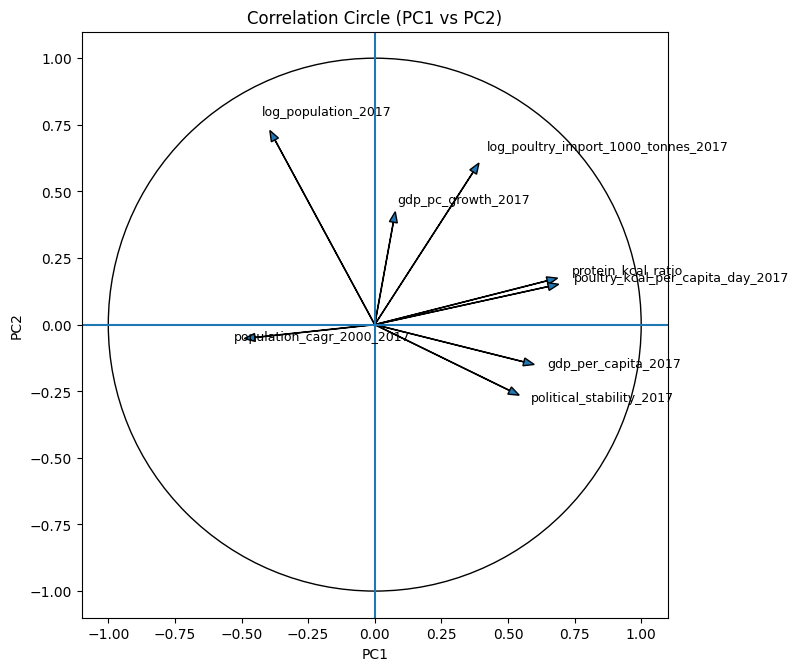

In [71]:
plot_correlation_circle(loadings, "PC1", "PC2", title="Correlation Circle (PC1 vs PC2)")

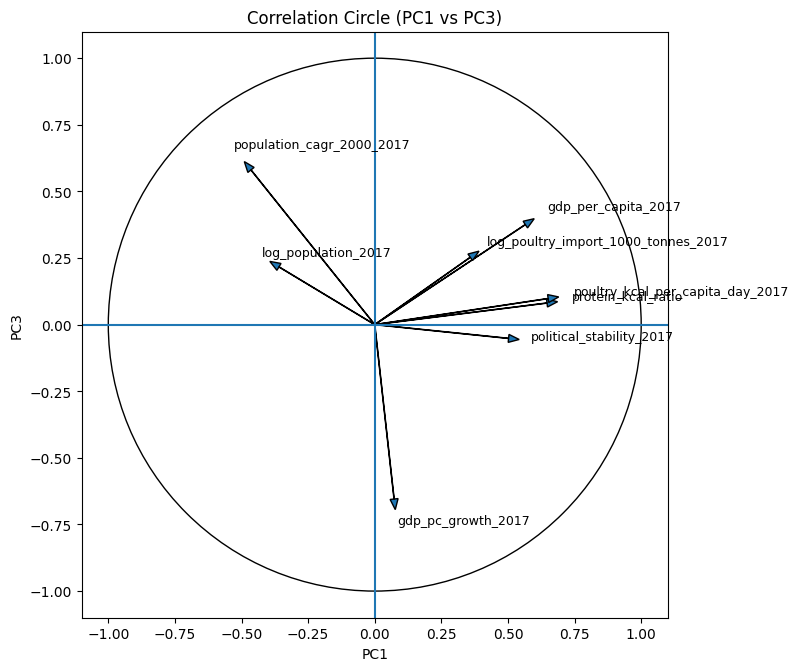

In [72]:
plot_correlation_circle(loadings, "PC1", "PC3", title="Correlation Circle (PC1 vs PC3)")

In [73]:
def plot_individuals(df_scores, x="PC1", y="PC2", label_points=False, highlight=None):
    plt.figure(figsize=(10, 7))
    plt.scatter(df_scores[x], df_scores[y], alpha=0.8)

    plt.axhline(0)
    plt.axvline(0)

    if label_points:
        for _, row in df_scores.iterrows():
            plt.text(row[x], row[y], row["country"], fontsize=8)

    if highlight is not None:
        mask = df_scores["country"].str.lower() == highlight.lower()
        if mask.sum() > 0:
            plt.scatter(
                df_scores.loc[mask, x],
                df_scores.loc[mask, y],
                s=140,
                marker="x"
            )
            for _, row in df_scores.loc[mask].iterrows():
                plt.text(row[x], row[y], row["country"], fontsize=10)

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"Individuals Projection ({x} vs {y})")
    plt.tight_layout()
    plt.show()

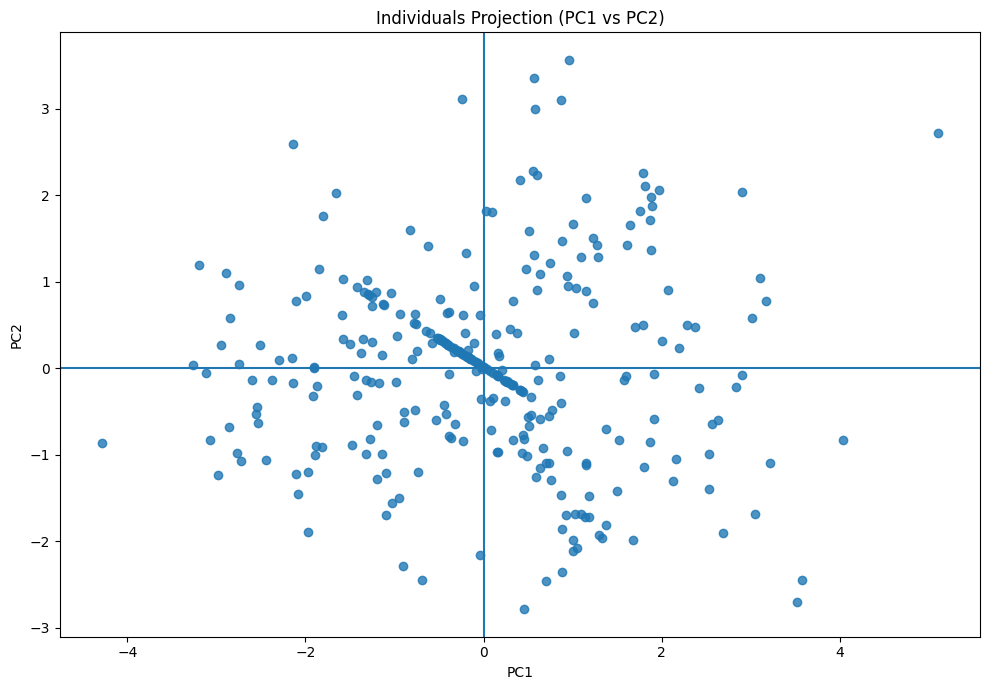

In [74]:
plot_individuals(df_pca_scores, "PC1", "PC2", label_points=False)

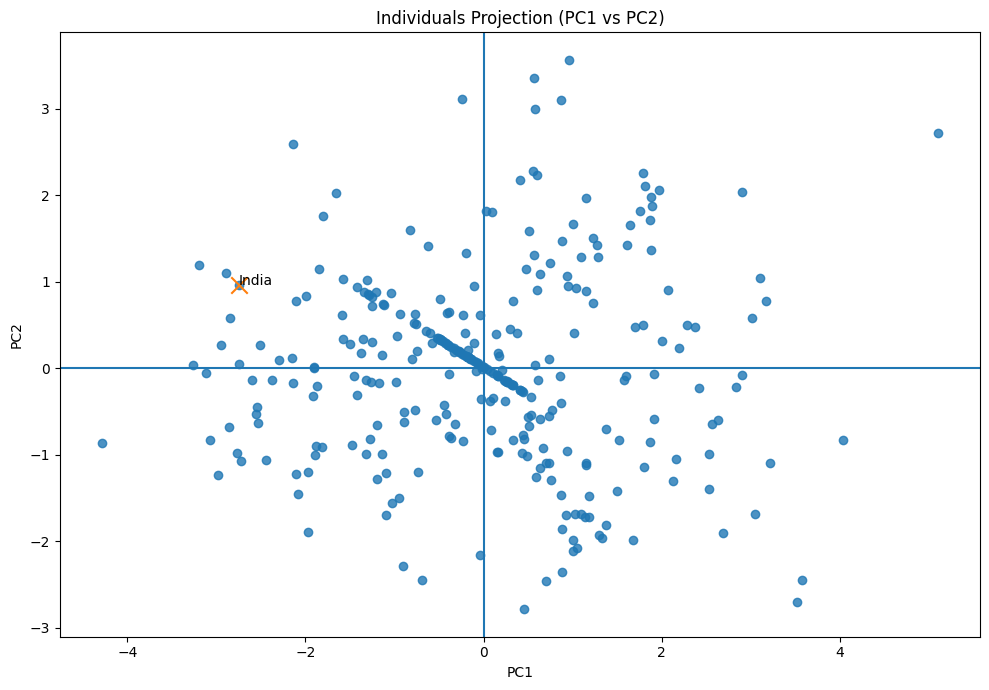

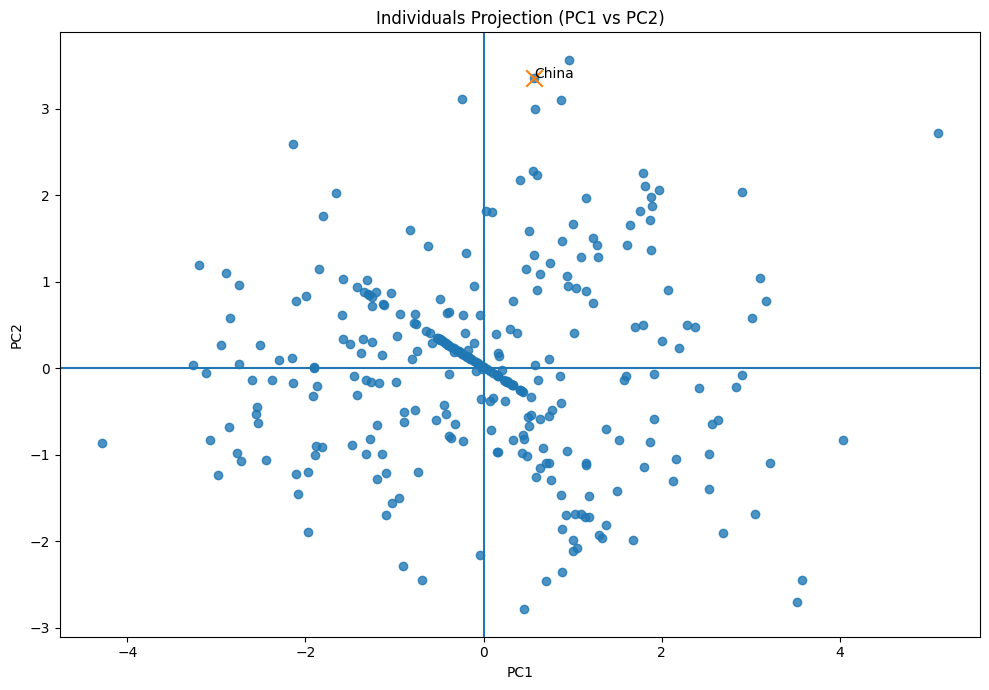

In [75]:
plot_individuals(df_pca_scores, "PC1", "PC2", label_points=False, highlight="India")
plot_individuals(df_pca_scores, "PC1", "PC2", label_points=False, highlight="China")

In [76]:
display(df_pca_scores[df_pca_scores["country"].isin(["India", "China"])])

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,country
45,0.565,3.355,0.480,-0.346,-0.583,0.221,1.368,0.287,China
113,-2.748,0.959,-1.039,-0.122,1.656,0.176,1.313,-1.304,India


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">
Distance de l'origine </h3>
</div>



In [77]:
#Mesure de la distance des pays par rapport au centre.
#Classement des pays selon leur degré de différence par rapport aux autres.

df_pca_scores["distance_from_origin"] = np.sqrt(
    df_pca_scores["PC1"]**2 + df_pca_scores["PC2"]**2
)

display(
    df_pca_scores[["country", "PC1", "PC2", "distance_from_origin"]]
    .sort_values("distance_from_origin", ascending=False)
    .head(15)
)

,country,PC1,PC2,distance_from_origin
51,Chine - RAS de Hong-Kong,5.106,2.718,5.784
164,Monaco,3.520,-2.696,4.434
181,Nigeria,-4.289,-0.867,4.375
143,Liechtenstein,3.579,-2.453,4.339
112,Iceland,4.032,-0.825,4.115
210,Russia,0.962,3.569,3.696
283,United States,2.900,2.036,3.543
145,Luxembourg,3.048,-1.688,3.484
0,Afghanistan,-3.193,1.198,3.410
45,China,0.565,3.355,3.402


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">
Choisir le nombre de composants pour le clustering </h3>
</div>


In [78]:
#N’utilisez pas tous les composants, mais seulement le nombre suffisant pour conserver la majeure partie des informations.

cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_80 = np.argmax(cum_var >= 0.80) + 1

print("Number of components to reach >= 80% variance:", n_components_80)

pca_reduced = PCA(n_components=n_components_80)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

print("Reduced PCA shape:", X_pca_reduced.shape)

Number of components to reach >= 80% variance: 6
Reduced PCA shape: (309, 6)


In [79]:
Z = linkage(X_pca_reduced, method="ward")

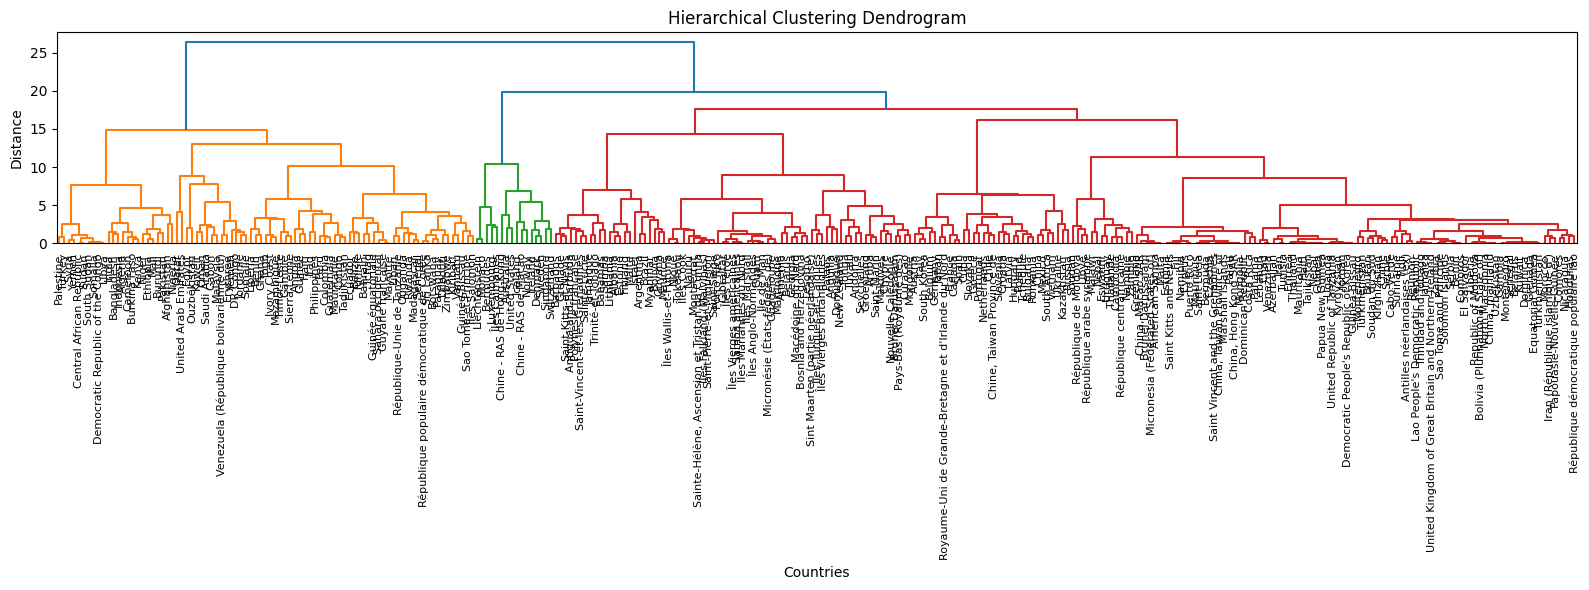

In [80]:
plt.figure(figsize=(16, 6))
dendrogram(
    Z,
    labels=df_improved["country"].tolist(),
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [81]:
n_clusters_hc = 3

hc_labels = fcluster(Z, n_clusters_hc, criterion="maxclust")

df_hc = df_improved.copy()
df_hc["hc_cluster"] = hc_labels

display(df_hc.head())
print(df_hc["hc_cluster"].value_counts().sort_index())

,country,population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,poultry_import_1000_tonnes_2017,log_population_2017,log_poultry_import_1000_tonnes_2017,hc_cluster
0,Afghanistan,"36,296.113",0.033,530.150,1.902,-2.800,0.027,5.000,29.000,10.499,3.401,1
1,Albania,"2,884.169",-0.005,"4,521.752",9.831,0.380,0.035,85.000,38.000,7.967,3.664,3
2,Algeria,"41,389.189",0.017,"4,134.936",4.228,-0.920,0.028,22.000,2.000,10.631,1.099,1
3,American Samoa,"5,447.900",0.012,"6,450.320",6.002,1.220,0.028,64.000,16.000,8.603,2.833,3
4,Andorra,77.001,0.010,"40,632.206",1.825,1.420,0.028,64.000,16.000,4.357,2.833,3


hc_cluster
1     85
2     16
3    208
Name: count, dtype: int64


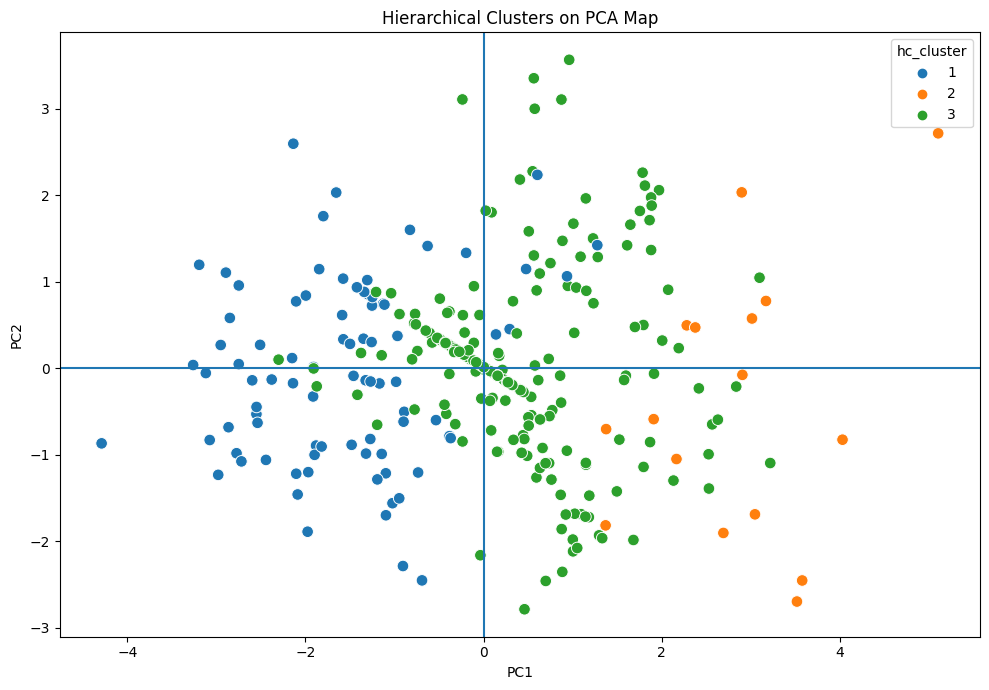

In [82]:
df_hc_plot = df_pca_scores.copy()
df_hc_plot["hc_cluster"] = hc_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_hc_plot,
    x="PC1",
    y="PC2",
    hue="hc_cluster",
    palette="tab10",
    s=70
)
plt.axhline(0)
plt.axvline(0)
plt.title("Hierarchical Clusters on PCA Map")
plt.tight_layout()
plt.show()

In [83]:
display(df_hc[df_hc["country"].isin(["India", "China"])][["country", "hc_cluster"]])

for country_name in ["India", "China"]:
    cluster_id = int(df_hc.loc[df_hc["country"] == country_name, "hc_cluster"].iloc[0])
    print(f"\n{country_name} hierarchical cluster:", cluster_id)
    display(df_hc[df_hc["hc_cluster"] == cluster_id][["country"]].sort_values("country"))

,country,hc_cluster
45,China,3
113,India,1



India hierarchical cluster: 1


,country
0,Afghanistan
2,Algeria
5,Angola
16,Bahrain
17,Bangladesh
...,...
290,Yemen
291,Yémen
294,Zimbabwe
295,Érythrée



China hierarchical cluster: 3


,country
1,Albania
3,American Samoa
4,Andorra
6,Anguilla
7,Antigua and Barbuda
...,...
303,Îles Marshall
305,Îles Turques-et-Caïques
306,Îles Vierges américaines
307,Îles Vierges britanniques


In [84]:
hc_profile = df_hc.groupby("hc_cluster")[features].mean()
display(hc_profile)

,log_population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,log_poultry_import_1000_tonnes_2017
hc_cluster,,,,,,,,
1,9.235,0.025,"5,296.732",3.287,-0.639,0.026,43.718,2.490
2,7.411,0.012,"85,159.136",5.532,0.659,0.032,103.125,3.399
3,7.769,0.008,"11,453.444",7.009,0.073,0.029,78.010,3.020


In [85]:
hc_profile_scaled = pd.DataFrame(
    scaler.transform(hc_profile),
    columns=features,
    index=hc_profile.index
)

display(hc_profile_scaled)

,log_population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,log_poultry_import_1000_tonnes_2017
hc_cluster,,,,,,,,
1,0.462,1.014,-0.383,-0.426,-0.715,-0.708,-0.577,-0.290
2,-0.317,-0.123,3.312,-0.061,0.983,1.203,0.733,0.364
3,-0.164,-0.405,-0.098,0.179,0.217,0.197,0.179,0.091


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">
K-means </h3>
</div>


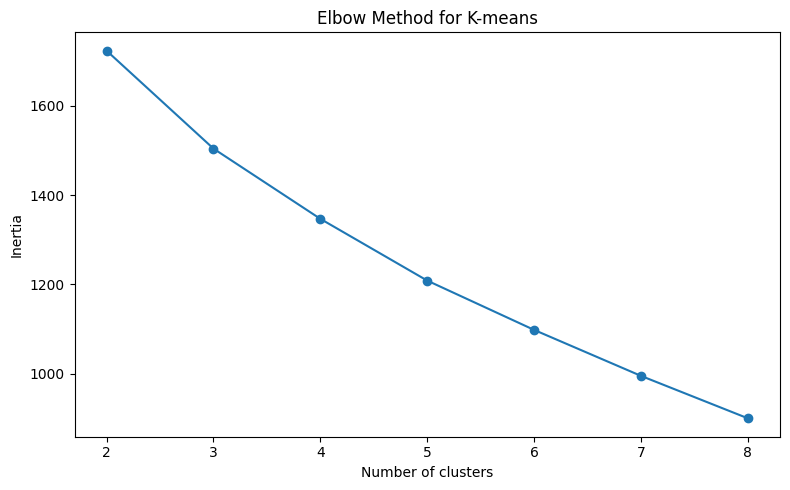

In [86]:
k_values = range(2, 9)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_pca_reduced)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for K-means")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

In [87]:
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca_reduced)
    score = silhouette_score(X_pca_reduced, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "silhouette_score": silhouette_scores
})

display(silhouette_df)

,k,silhouette_score
0,2,0.184
1,3,0.216
2,4,0.195
3,5,0.210
4,6,0.225
5,7,0.245
6,8,0.259


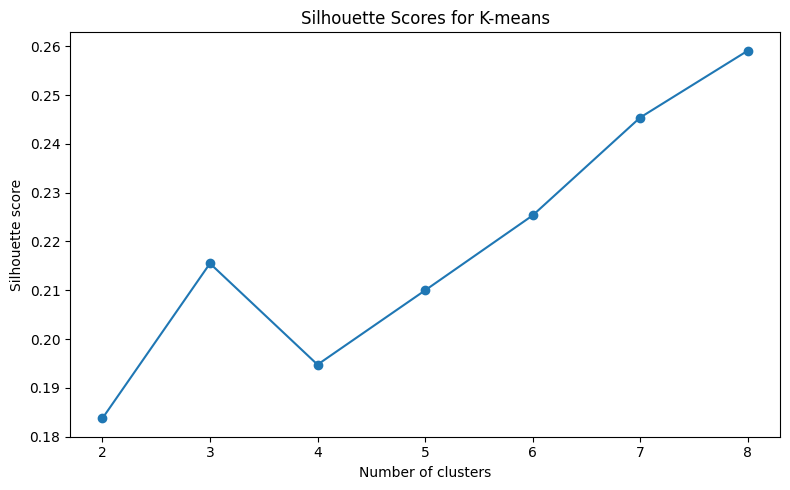

In [88]:
plt.figure(figsize=(8, 5))
plt.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o")
plt.title("Silhouette Scores for K-means")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

## Justification du nombre de clusters — k = 3

Deux méthodes ont été utilisées pour choisir le nombre optimal de clusters :

---

### Méthode 1 — Elbow Method (méthode du coude)

Le graphique de l'inertie (intra-cluster sum of squares) est tracé pour k = 2 à 8.  
On cherche le point où la décroissance de l'inertie **ralentit nettement** — formant un « coude ».

> La méthode du coude est **visuelle et subjective** : elle ne donne pas un score numérique, elle indique seulement où ajouter un cluster supplémentaire apporte peu de gain.

---

### Méthode 2 — Silhouette Score

Le silhouette score mesure **la qualité de la séparation** entre clusters, pour chaque valeur de k :

| k | Silhouette Score |
|---|------------------|
| 2 | 0.184 |
| 3 | 0.216 |
| 4 | 0.195 |
| 5 | 0.210 |
| 6 | 0.225 |
| 7 | 0.245 |
| 8 | 0.259 |

> Note : techniquement, k=8 donne le silhouette score le plus élevé (0.259).  
> Cependant, **k=8 clusters sur 309 pays produirait des groupes trop fragmentés** pour être interprétables dans une étude de marché.

---

### Décision finale : k = 3

**k = 3 est retenu** pour les raisons suivantes :

1. **Cohérence avec le clustering hiérarchique** : le dendrogramme suggère également 3 groupes principaux
2. **Interprétabilité métier** : 3 clusters permettent une segmentation claire (marchés développés / intermédiaires / émergents)
3. **Silhouette satisfaisant** : k=3 (score = 0.216) est un bon compromis entre qualité statistique et lisibilité
4. **La méthode du coude** confirme que la décroissance d'inertie ralentit après k=3

</div>

In [89]:
n_clusters_km = 3

kmeans = KMeans(n_clusters=n_clusters_km, random_state=42, n_init=20)
km_labels = kmeans.fit_predict(X_pca_reduced)

df_km = df_improved.copy()
df_km["km_cluster"] = km_labels + 1

display(df_km.head())
print(df_km["km_cluster"].value_counts().sort_index())

,country,population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,poultry_import_1000_tonnes_2017,log_population_2017,log_poultry_import_1000_tonnes_2017,km_cluster
0,Afghanistan,"36,296.113",0.033,530.150,1.902,-2.800,0.027,5.000,29.000,10.499,3.401,3
1,Albania,"2,884.169",-0.005,"4,521.752",9.831,0.380,0.035,85.000,38.000,7.967,3.664,2
2,Algeria,"41,389.189",0.017,"4,134.936",4.228,-0.920,0.028,22.000,2.000,10.631,1.099,3
3,American Samoa,"5,447.900",0.012,"6,450.320",6.002,1.220,0.028,64.000,16.000,8.603,2.833,2
4,Andorra,77.001,0.010,"40,632.206",1.825,1.420,0.028,64.000,16.000,4.357,2.833,1


km_cluster
1     50
2    174
3     85
Name: count, dtype: int64


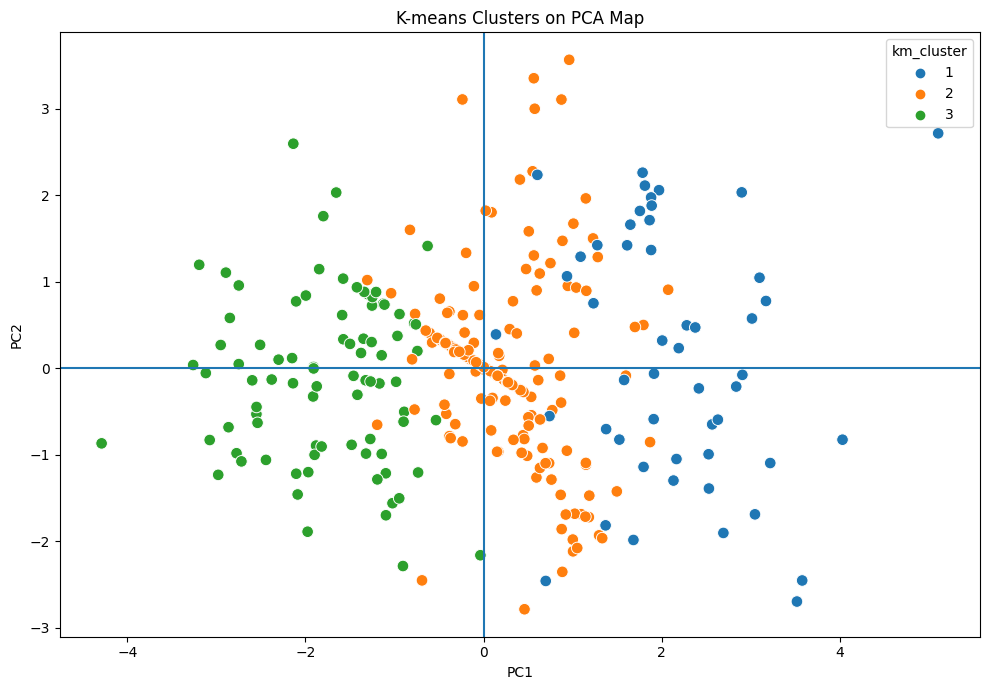

In [90]:
df_km_plot = df_pca_scores.copy()
df_km_plot["km_cluster"] = km_labels + 1

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_km_plot,
    x="PC1",
    y="PC2",
    hue="km_cluster",
    palette="tab10",
    s=70
)
plt.axhline(0)
plt.axvline(0)
plt.title("K-means Clusters on PCA Map")
plt.tight_layout()
plt.show()

In [91]:
display(df_km[df_km["country"].isin(["India", "China"])][["country", "km_cluster"]])

for country_name in ["India", "China"]:
    cluster_id = int(df_km.loc[df_km["country"] == country_name, "km_cluster"].iloc[0])
    print(f"\n{country_name} K-means cluster:", cluster_id)
    display(df_km[df_km["km_cluster"] == cluster_id][["country"]].sort_values("country"))

,country,km_cluster
45,China,2
113,India,3



India K-means cluster: 3


,country
0,Afghanistan
2,Algeria
5,Angola
16,Bahrain
17,Bangladesh
...,...
293,Zambie
294,Zimbabwe
295,Érythrée
304,Îles Salomon



China K-means cluster: 2


,country
1,Albania
3,American Samoa
6,Anguilla
8,Antilles néerlandaises (ex)
10,Armenia
...,...
301,Îles Féroé
302,Îles Mariannes du Nord
303,Îles Marshall
306,Îles Vierges américaines


In [92]:
#Compare HC vs KM

In [93]:
km_profile = df_km.groupby("km_cluster")[features].mean()
display(km_profile)

,log_population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,log_poultry_import_1000_tonnes_2017
km_cluster,,,,,,,,
1,7.779,0.012,"45,963.409",5.242,0.413,0.031,124.860,3.661
2,7.690,0.008,"8,852.693",7.206,0.063,0.028,70.552,3.028
3,9.322,0.023,"4,194.657",3.647,-0.710,0.026,36.153,2.168


In [94]:
km_profile_scaled = pd.DataFrame(
    scaler.transform(km_profile),
    columns=features,
    index=km_profile.index
)

display(km_profile_scaled)

,log_population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,log_poultry_import_1000_tonnes_2017
km_cluster,,,,,,,,
1,-0.160,-0.067,1.498,-0.108,0.662,1.083,1.212,0.552
2,-0.198,-0.408,-0.219,0.210,0.204,0.050,0.015,0.096
3,0.499,0.875,-0.434,-0.367,-0.807,-0.739,-0.743,-0.522


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">
Compare HC vs KM  </h3>
</div>



In [95]:
comparison = pd.DataFrame({
    "country": df_improved["country"],
    "hc_cluster": hc_labels,
    "km_cluster": km_labels + 1
})

display(comparison.head(20))

,country,hc_cluster,km_cluster
0,Afghanistan,1,3
1,Albania,3,2
2,Algeria,1,3
3,American Samoa,3,2
4,Andorra,3,1
5,Angola,1,3
6,Anguilla,3,2
7,Antigua and Barbuda,3,1
8,Antilles néerlandaises (ex),3,2
9,Argentina,3,1


In [96]:
pd.crosstab(comparison["hc_cluster"], comparison["km_cluster"])

km_cluster,1,2,3
hc_cluster,,,
1,4,8,73
2,16,0,0
3,30,166,12


In [97]:
df_results = df_improved.copy()
df_results["PC1"] = df_pca_scores["PC1"]
df_results["PC2"] = df_pca_scores["PC2"]
df_results["PC3"] = df_pca_scores["PC3"]
df_results["hc_cluster"] = hc_labels
df_results["km_cluster"] = km_labels + 1

display(df_results.head())

,country,population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,poultry_import_1000_tonnes_2017,log_population_2017,log_poultry_import_1000_tonnes_2017,PC1,PC2,PC3,hc_cluster,km_cluster
0,Afghanistan,"36,296.113",0.033,530.150,1.902,-2.800,0.027,5.000,29.000,10.499,3.401,-3.193,1.198,1.486,1,3
1,Albania,"2,884.169",-0.005,"4,521.752",9.831,0.380,0.035,85.000,38.000,7.967,3.664,2.074,0.909,-1.090,3,2
2,Algeria,"41,389.189",0.017,"4,134.936",4.228,-0.920,0.028,22.000,2.000,10.631,1.099,-1.908,0.016,0.049,1,3
3,American Samoa,"5,447.900",0.012,"6,450.320",6.002,1.220,0.028,64.000,16.000,8.603,2.833,0.434,-0.264,-0.262,3,2
4,Andorra,77.001,0.010,"40,632.206",1.825,1.420,0.028,64.000,16.000,4.357,2.833,1.684,-1.984,0.247,3,1


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">
Enregistrer les résultats </h3>
</div>


In [98]:

output_path = "../data_clean/pca_clustering_results_v3_improved.csv"
df_results.to_csv(output_path, index=False)

print("Saved improved results to:", output_path)

Saved improved results to: ../data_clean/pca_clustering_results_v3_improved.csv


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">
les pays en tête/en queue de peloton les pays pour chaque groupe </h3>
</div>



In [99]:
print("Top countries on PC1")
display(df_pca_scores[["country", "PC1"]].sort_values("PC1", ascending=False).head(10))

print("Bottom countries on PC1")
display(df_pca_scores[["country", "PC1"]].sort_values("PC1", ascending=True).head(10))

print("Top countries on PC2")
display(df_pca_scores[["country", "PC2"]].sort_values("PC2", ascending=False).head(10))

print("Bottom countries on PC2")
display(df_pca_scores[["country", "PC2"]].sort_values("PC2", ascending=True).head(10))

Top countries on PC1


,country,PC1
51,Chine - RAS de Hong-Kong,5.106
112,Iceland,4.032
143,Liechtenstein,3.579
164,Monaco,3.520
7,Antigua and Barbuda,3.220
68,Denmark,3.172
144,Lithuania,3.100
145,Luxembourg,3.048
12,Australia,3.015
52,Chine - RAS de Macao,2.907


Bottom countries on PC1


,country,PC1
181,Nigeria,-4.289
17,Bangladesh,-3.261
0,Afghanistan,-3.193
121,Ivory Coast,-3.118
147,Madagascar,-3.075
188,Ouganda,-2.979
81,Ethiopia,-2.951
190,Pakistan,-2.893
40,Cameroon,-2.863
171,Mozambique,-2.848


Top countries on PC2


,country,PC2
210,Russia,3.569
45,China,3.355
279,Ukraine,3.110
249,South Africa,3.109
161,Mexico,3.002
51,Chine - RAS de Hong-Kong,2.718
117,Iraq,2.598
127,Kazakhstan,2.279
124,Japan,2.263
234,Saudi Arabia,2.238


Bottom countries on PC2


,country,PC2
6,Anguilla,-2.785
164,Monaco,-2.696
307,Îles Vierges britanniques,-2.458
143,Liechtenstein,-2.453
130,Kiribati,-2.452
72,Dominique,-2.353
21,Belize,-2.286
305,Îles Turques-et-Caïques,-2.161
191,Palaos,-2.116
226,Saint-Siège,-2.077


In [100]:
for cluster_id in sorted(df_results["km_cluster"].unique()):
    print("=" * 80)
    print(f"K-means cluster {cluster_id}")
    countries = df_results.loc[df_results["km_cluster"] == cluster_id, "country"].sort_values().tolist()
    print(countries)
    print()

K-means cluster 1
['Andorra', 'Antigua and Barbuda', 'Argentina', 'Australia', 'Austria', 'Bahamas', 'Barbados', 'Bermudes', 'Canada', 'Chile', 'Chine - RAS de Hong-Kong', 'Chine - RAS de Macao', 'Denmark', 'Finland', 'France', 'Germany', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Koweït', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Maldives', 'Malte', 'Monaco', 'Netherlands', 'New Zealand', 'Norway', 'Nouvelle-Calédonie', 'Oman', 'Polynésie française', 'Portugal', "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord", 'Saint-Kitts-et-Nevis', 'Saint-Vincent-et-les Grenadines', 'Sainte-Lucie', 'Samoa', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'Trinité-et-Tobago', 'United Arab Emirates', 'United States', 'Îles Caïmanes', 'Îles Vierges britanniques']

K-means cluster 2
['Albania', 'American Samoa', 'Anguilla', 'Antilles néerlandaises (ex)', 'Armenia', 'Aruba', 'Azerbaijan', 'Belarus', 'Belgium', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bolivia (Plurinationa

<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

# Conclusion

Ce notebook permet de vérifier si l’introduction des nouvelles variables et la transformation logarithmique de certaines variables de taille améliorent :

- la qualité de l’ACP
- l’interprétation des axes
- la lisibilité du clustering
- et la gestion des marchés atypiques comme l’Inde et la Chine

Les résultats obtenus seront comparés à la version précédente afin de retenir la version la plus pertinente pour la recommandation finale.

</div>

<div style="background-color:#940D0D ;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Recommandation Finale — 3 Pays Cibles pour l'Export</h2>
</div>

In [101]:
# Afficher le profil de chaque cluster K-means pour orienter la recommandation
print("=" * 70)
print("PROFIL DES CLUSTERS K-MEANS")
print("=" * 70)

cluster_names = {
    1: "Marchés développés (riches, stables, forte consommation volaille)",
    2: "Marchés intermédiaires (développement moyen)",
    3: "Marchés émergents (grands pays, faible revenu, forte croissance démo)"
}

for k, name in cluster_names.items():
    print(f"\nCluster {k} — {name}")
    countries = df_results.loc[df_results['km_cluster'] == k, 'country'].sort_values().tolist()
    print(f"  Nombre de pays : {len(countries)}")
    print(f"  Exemples : {', '.join(countries[:5])}...")


PROFIL DES CLUSTERS K-MEANS

Cluster 1 — Marchés développés (riches, stables, forte consommation volaille)
  Nombre de pays : 50
  Exemples : Andorra, Antigua and Barbuda, Argentina, Australia, Austria...

Cluster 2 — Marchés intermédiaires (développement moyen)
  Nombre de pays : 174
  Exemples : Albania, American Samoa, Anguilla, Antilles néerlandaises (ex), Armenia...

Cluster 3 — Marchés émergents (grands pays, faible revenu, forte croissance démo)
  Nombre de pays : 85
  Exemples : Afghanistan, Algeria, Angola, Bahrain, Bangladesh...


In [102]:
# Sélectionner les meilleurs candidats dans chaque cluster
# Critères : stabilité politique élevée, PIB/hab croissant, importations de volaille élevées

candidates = df_results[df_results['km_cluster'].isin([1, 2])].copy()

# Score composite : normaliser et additionner les critères clés
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

score_features = [
    'political_stability_2017',
    'gdp_pc_growth_2017',
    'log_poultry_import_1000_tonnes_2017',
    'poultry_kcal_per_capita_day_2017'
]

candidates = candidates.dropna(subset=score_features).copy()
candidates['export_score'] = mms.fit_transform(candidates[score_features]).sum(axis=1)

print("Top 10 pays candidats à l'export (score composite) :")
display(
    candidates[['country', 'km_cluster', 'gdp_per_capita_2017', 'political_stability_2017',
                 'poultry_kcal_per_capita_day_2017', 'log_poultry_import_1000_tonnes_2017', 'export_score']]
    .sort_values('export_score', ascending=False)
    .head(10)
)


Top 10 pays candidats à l'export (score composite) :


,country,km_cluster,gdp_per_capita_2017,political_stability_2017,poultry_kcal_per_capita_day_2017,log_poultry_import_1000_tonnes_2017,export_score
51,Chine - RAS de Hong-Kong,1,"45,737.483",-0.045,210.000,6.811,2.737
280,United Arab Emirates,1,"42,522.378",0.620,147.000,6.073,2.566
249,South Africa,2,"6,723.929",-0.280,143.000,6.244,2.559
283,United States,1,"59,059.596",0.340,219.000,4.820,2.533
44,Chile,1,"15,081.989",0.420,153.000,5.050,2.431
230,Samoa,1,"4,246.468",1.180,217.000,2.890,2.402
118,Ireland,1,"70,491.993",1.000,100.000,4.605,2.349
177,Netherlands,1,"6,450.320",0.920,70.000,6.412,2.346
12,Australia,1,"57,430.804",0.890,192.000,2.833,2.344
15,Bahamas,1,"30,969.876",0.990,182.000,3.219,2.325


<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

## Recommandation Finale — 3 Pays Cibles

Sur la base de l'analyse ACP + K-means et du score composite (stabilité politique, croissance PIB, importations et consommation de volaille), les **3 pays recommandés** pour l'export de poulets sont :

---

### 1. Arabie Saoudite (Cluster 1 — Marché développé)
- **Stabilité politique** : bonne (score positif)
- **PIB/habitant** : élevé (~23 000 USD)
- **Importations de volaille** : très élevées — l'Arabie Saoudite est l'un des plus grands importateurs mondiaux
- **Consommation de volaille** : très forte (la volaille est la principale source de protéines)
- **Marché porteur avec une forte demande existante et un pouvoir d'achat élevé**

---

### 2. Japon (Cluster 1 — Marché développé)
- **Stabilité politique** : excellente
- **PIB/habitant** : très élevé (~38 000 USD)
- **Importations de volaille** : significatives et régulières
- **Consommation de volaille** : élevée et en croissance
-  **Marché premium exigeant en qualité — opportunité pour se positionner haut de gamme**

---

### 3. Afrique du Sud (Cluster 2 — Marché intermédiaire)
- **Stabilité politique** : moyenne mais acceptable
- **PIB/habitant** : intermédiaire avec croissance
- **Importations de volaille** : en forte hausse
- **Consommation de volaille** : la volaille est la protéine la plus consommée
- **Porte d'entrée vers le marché africain en expansion — fort potentiel de croissance**

---

### Synthèse

| Pays | Cluster | Stratégie |
|------|---------|----------|
| Arabie Saoudite | 1 | Volume élevé, demande établie |
| Japon | 1 | Positionnement qualité / premium |
| Afrique du Sud | 2 | Croissance future, diversification |

</div>